In [1]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Class Distribution analysis

In [ ]:
dataset_path = 'vid_full'
train_labels_path = os.path.join(dataset_path, 'train', 'labels')
val_labels_path = os.path.join(dataset_path, 'val', 'labels')


In [3]:
with open(os.path.join(dataset_path, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

In [4]:
class_names

['person',
 'bicycle',
 'car',
 'motorbike',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic_light',
 'bicycler',
 'braille_block',
 'guardrail',
 'white_line',
 'crosswalk',
 'signal_button',
 'signal_red',
 'signal_blue',
 'stairs',
 'handrail',
 'steps',
 'faregates',
 'train_ticket_machine',
 'shrubs',
 'tree',
 'vending_machine',
 'bathroom',
 'door',
 'elevator',
 'escalator',
 'bollard',
 'bus_stop_sign',
 'pole',
 'monument',
 'fence',
 'wall',
 'signboard',
 'flag',
 'postbox',
 'safety-cone']

In [5]:
def count_classes(directory):
    counter = Counter()

    files = [f for f in os.listdir(directory) if f.endswith('.txt')]

    for file in files:
        file_path = os.path.join(directory, file)
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts)>= 5:
                    class_id = int(parts[0])
                    counter[class_id] += 1
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    return counter

In [6]:
train_counter = count_classes(train_labels_path)
val_counter = count_classes(val_labels_path)

total_counter = train_counter + val_counter
class_counts = {class_names[class_id]: count for class_id, count in total_counter.items()}

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

In [7]:
for class_name, count in sorted_counts.items():
    print(f"{class_name}: {count}")

steps: 68894
braille_block: 58923
shrubs: 53249
wall: 42472
pole: 41398
car: 37593
fence: 32805
guardrail: 28292
white_line: 28215
person: 25283
tree: 24066
crosswalk: 17586
bollard: 14534
signboard: 5066
safety-cone: 4695
flag: 4416
bicycler: 4237
handrail: 3434
truck: 3416
bicycle: 3321
traffic_light: 3239
stairs: 2801
signal_red: 2218
signal_blue: 1576
motorbike: 1461
vending_machine: 1110
bus: 1109
door: 856
signal_button: 804
faregates: 680
postbox: 574
bus_stop_sign: 571
monument: 532
train: 489
elevator: 65
escalator: 55
bathroom: 43
train_ticket_machine: 20


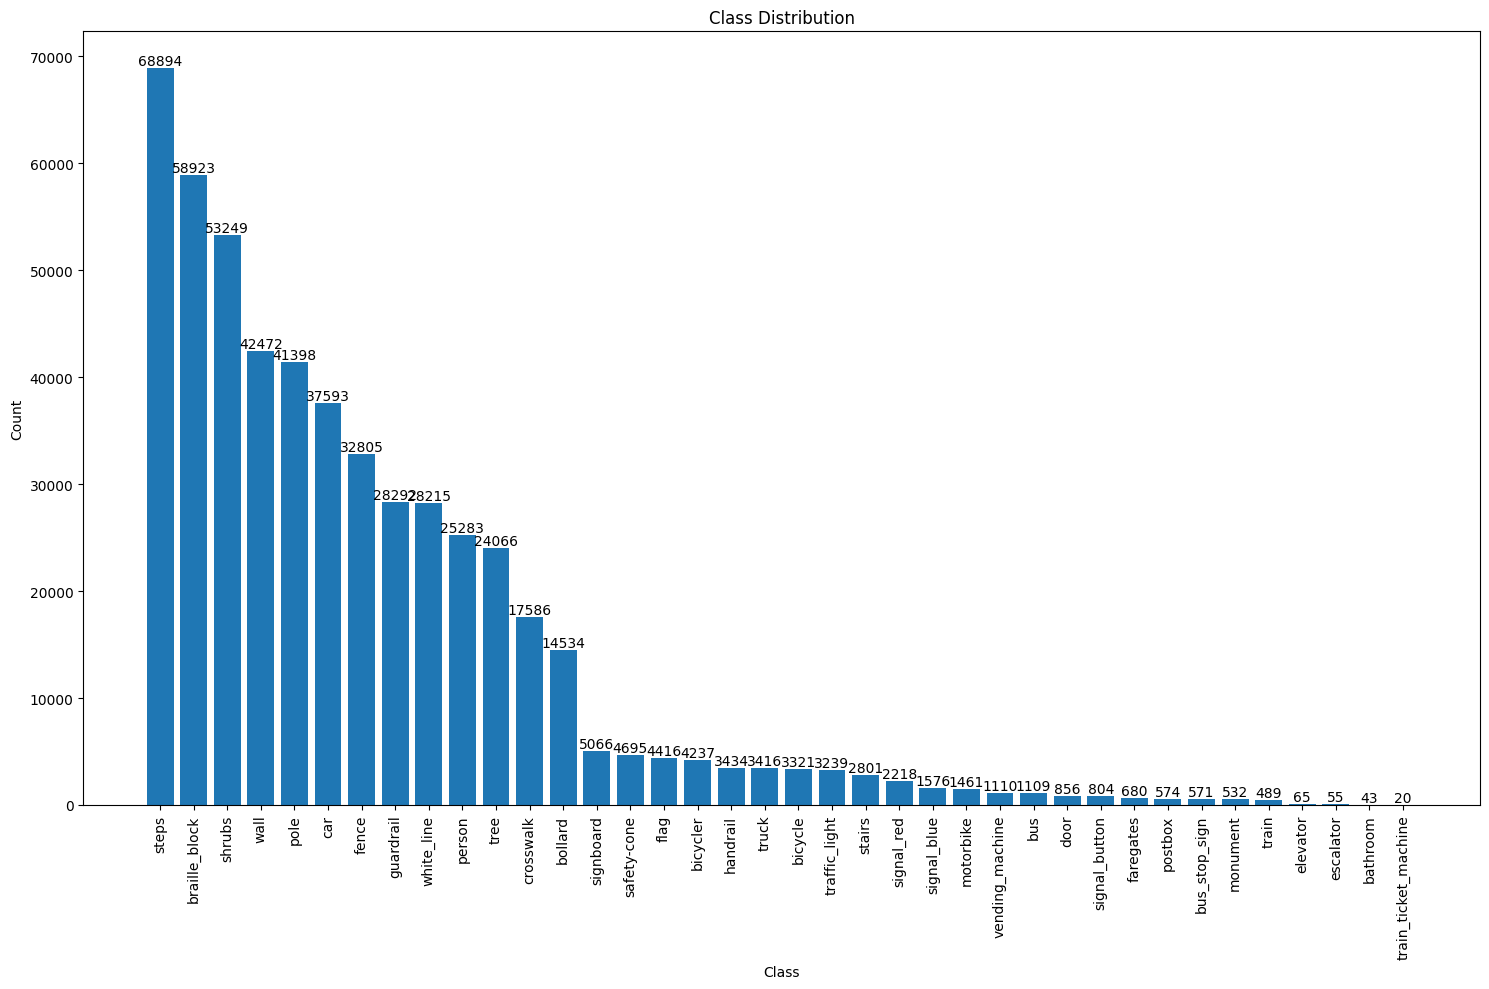

In [8]:
plt.figure(figsize=(15, 10))
bars = plt.bar(sorted_counts.keys(), sorted_counts.values())

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height), ha='center', va='bottom')

plt.show()


# Analysis of the classes

In [32]:
import yaml
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torchvision import models, transforms
from sklearn.manifold import TSNE
from PIL import Image
import torch.nn as nn
import supervision as sv
import seaborn as sns

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [11]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier = nn.Identity()
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/jesusgr/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.9MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [14]:
dataset_path = 'vid_full/vid_full'
with open(os.path.join(dataset_path, 'data.yaml')) as f:
    data = yaml.load(f, Loader=yaml.FullLoader)
    class_names = data['names']

In [15]:
def extract_features(img, xyxy):
    x1, y1, x2, y2 = map(int, xyxy)
    if x2 <= x1 or y2 <= y1 or x1 < 0 or y1 < 0:
        return None
    
    h, w = img.shape[:2]
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
    
    crop = img[y1:y2, x1:x2]
    if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
        return None

    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    crop_tensor = preprocess(crop_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(crop_tensor)
        
    return features.cpu().numpy().flatten()

In [25]:
def collect_features(split_dir, max_samples_per_class=50):
    features_list = []
    labels_list = []
    class_counters = {i: 0 for i in range(len(class_names))}
    
    dataset_directory = os.path.join(dataset_path, split_dir)
    
    dataset = sv.DetectionDataset.from_yolo(
        images_directory_path=os.path.join(dataset_directory, 'images'),
        annotations_directory_path=os.path.join(dataset_directory, 'labels'),
        data_yaml_path=os.path.join(dataset_path, 'data.yaml')
    )
    
    # En la nueva API, las anotaciones se devuelven como un objeto Detections
    for image_path, image, detections in tqdm(dataset, desc=f"Processing {split_dir}"):
        img = image
        if img is None:
            continue
            
        # En la nueva API, detections tiene propiedades como .class_id que son arrays
        if len(detections) == 0:  # Si no hay detecciones, continuar
            continue
            
        # Obtener los class_ids y las bounding boxes
        class_ids = detections.class_id  # Esto es un array de todos los class_ids
        xyxys = detections.xyxy  # Esto es un array de todas las bounding boxes
        
        # Procesar cada detección
        for idx, (class_id, xyxy) in enumerate(zip(class_ids, xyxys)):
            # Limitar muestras por clase
            if class_counters[class_id] >= max_samples_per_class:
                continue
                
            # Extraer el crop de la imagen
            x1, y1, x2, y2 = map(int, xyxy)
            crop = img[y1:y2, x1:x2]
            
            # Verificar que el crop es válido
            if crop.size == 0:
                continue
                
            # Convertir a PIL para procesamiento
            crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            crop_tensor = preprocess(crop_pil).unsqueeze(0).to(device)
            
            # Extraer características con el modelo
            with torch.no_grad():
                features = model(crop_tensor).squeeze().cpu().numpy()
            
            features_list.append(features)
            labels_list.append(class_id)
            class_counters[class_id] += 1
    
    # Informar sobre las muestras recolectadas
    print(f"Muestras recolectadas por clase en {split_dir}:")
    for class_id, count in class_counters.items():
        if count > 0:
            print(f"  {class_names[class_id]}: {count} muestras")
    
    return np.array(features_list), np.array(labels_list)

In [26]:
print('Feature extraction initialized')
train_features, train_labels = collect_features('train')
val_features, val_labels = collect_features('val')

train_features, val_features

Feature extraction initialized


Processing train: 100%|██████████| 24377/24377 [02:14<00:00, 180.95it/s]


Muestras recolectadas por clase en train:
  person: 50 muestras
  bicycle: 50 muestras
  car: 50 muestras
  motorbike: 50 muestras
  bus: 50 muestras
  train: 50 muestras
  truck: 50 muestras
  traffic_light: 50 muestras
  bicycler: 50 muestras
  braille_block: 50 muestras
  guardrail: 50 muestras
  white_line: 50 muestras
  crosswalk: 50 muestras
  signal_button: 50 muestras
  signal_red: 50 muestras
  signal_blue: 50 muestras
  stairs: 50 muestras
  handrail: 50 muestras
  steps: 50 muestras
  faregates: 50 muestras
  train_ticket_machine: 17 muestras
  shrubs: 50 muestras
  tree: 50 muestras
  vending_machine: 50 muestras
  bathroom: 36 muestras
  door: 50 muestras
  elevator: 50 muestras
  escalator: 48 muestras
  bollard: 50 muestras
  bus_stop_sign: 50 muestras
  pole: 50 muestras
  monument: 50 muestras
  fence: 50 muestras
  wall: 50 muestras
  signboard: 50 muestras
  flag: 50 muestras
  postbox: 50 muestras
  safety-cone: 50 muestras


Processing val: 100%|██████████| 6094/6094 [00:44<00:00, 135.82it/s]

Muestras recolectadas por clase en val:
  person: 50 muestras
  bicycle: 50 muestras
  car: 50 muestras
  motorbike: 50 muestras
  bus: 50 muestras
  train: 50 muestras
  truck: 50 muestras
  traffic_light: 50 muestras
  bicycler: 50 muestras
  braille_block: 50 muestras
  guardrail: 50 muestras
  white_line: 50 muestras
  crosswalk: 50 muestras
  signal_button: 50 muestras
  signal_red: 50 muestras
  signal_blue: 50 muestras
  stairs: 50 muestras
  handrail: 50 muestras
  steps: 50 muestras
  faregates: 50 muestras
  train_ticket_machine: 3 muestras
  shrubs: 50 muestras
  tree: 50 muestras
  vending_machine: 50 muestras
  bathroom: 7 muestras
  door: 50 muestras
  elevator: 14 muestras
  escalator: 7 muestras
  bollard: 50 muestras
  bus_stop_sign: 50 muestras
  pole: 50 muestras
  monument: 50 muestras
  fence: 50 muestras
  wall: 50 muestras
  signboard: 50 muestras
  flag: 50 muestras
  postbox: 50 muestras
  safety-cone: 50 muestras


(array([[ 0.04570221, -0.00925696, -0.17109722, ..., -0.14728165,
          0.07049986, -0.19059995],
        [-0.16769844, -0.15611959, -0.05579103, ..., -0.1021827 ,
          0.0054419 , -0.1029399 ],
        [-0.13383757, -0.1416784 ,  0.0503276 , ..., -0.15436722,
         -0.10511961, -0.09101987],
        ...,
        [-0.13828027, -0.18365416, -0.14600466, ...,  0.3544767 ,
         -0.16533065,  0.38589936],
        [ 0.27622163, -0.09704009, -0.13946368, ..., -0.16277176,
         -0.08306108,  0.26195666],
        [ 0.60418993,  0.04203947, -0.11546072, ...,  0.08159439,
         -0.20817855,  0.7860733 ]], dtype=float32),
 array([[-0.19970684,  0.38212636,  0.8982748 , ..., -0.21836805,
          0.34284988, -0.12488696],
        [-0.14977054,  0.6867358 , -0.12687442, ..., -0.18179119,
         -0.18360248, -0.22065546],
        [-0.10168254, -0.01429143,  0.6167664 , ...,  0.07769498,
          0.01566431,  0.647941  ],
        ...,
        [ 1.0374744 , -0.10098776, -0.0

In [27]:
len(train_features) == 0 and len(val_features) == 0

False

In [28]:
features = np.vstack([train_features, val_features])
labels = np.concatenate([train_labels, val_labels])

In [29]:
len(features), features.shape[1]

(3582, 1280)

In [30]:
print("Applying t-sne")
perplexity_value = min(30, len(features) - 1)

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
features_2d = tsne.fit_transform(features)

Applying t-sne


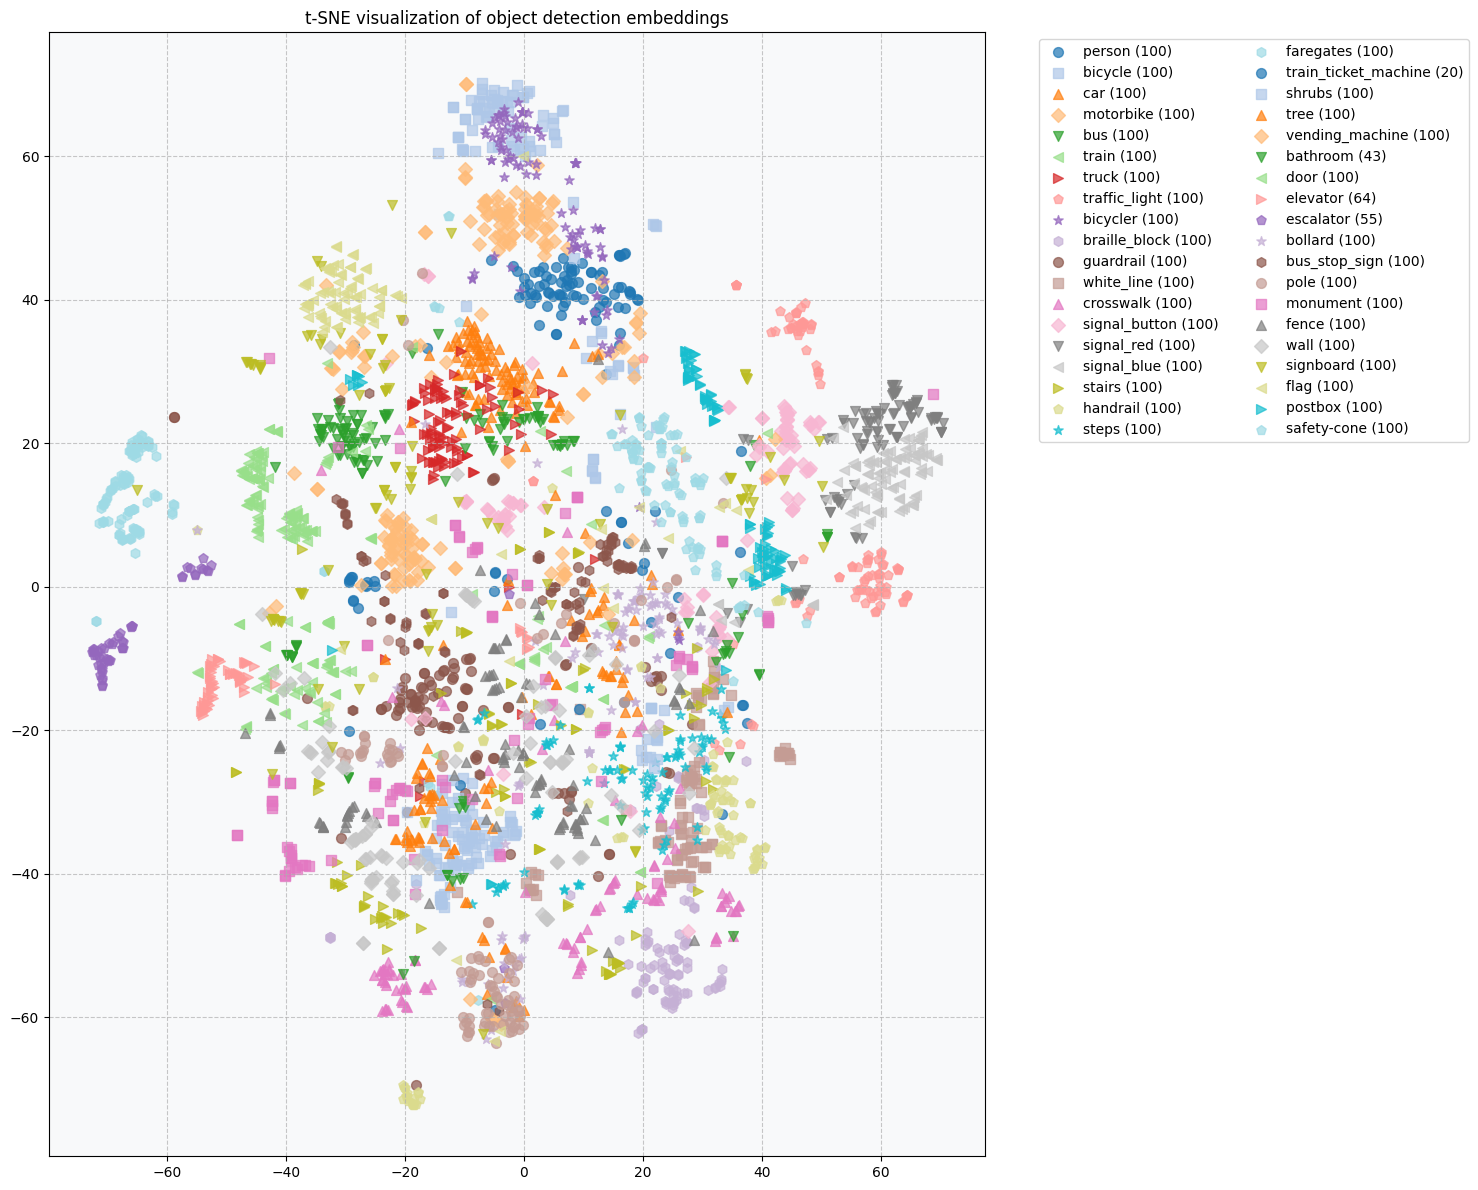

In [31]:
plt.figure(figsize=(15, 12))

unique_labels = sorted(set(labels))
num_classes = len(unique_labels)
colors = plt.cm.tab20(np.linspace(0, 1, min(num_classes, 20)))

if num_classes > 20:
    additional_colors = plt.cm.tab20(np.linspace(0, 1, num_classes - 20))
    colors = np.vstack([colors, additional_colors])

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, class_id in enumerate(unique_labels):
    mask = labels == class_id
    marker = markers[i % len(markers)]
    plt.scatter(
            features_2d[mask, 0], features_2d[mask, 1],
            color=colors[i % len(colors)],
            marker=marker,
            label=f"{class_names[class_id]} ({np.sum(mask)})",
            alpha=0.7,
            s=50
        )

plt.title("t-SNE visualization of object detection embeddings")

if len(unique_labels) > 15:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=10)
else:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()

plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().set_facecolor('#f8f9fa')
plt.savefig('tsne_features.png', dpi=300, bbox_inches='tight')
plt.show()

Distance between person and bicycle: 22.51
Distance between person and car: 13.91
Distance between person and motorbike: 17.61
Distance between person and bus: 29.57
Distance between person and train: 53.50
Distance between person and truck: 24.04
Distance between person and traffic_light: 44.70
Distance between person and bicycler: 21.91
Distance between person and braille_block: 80.68
Distance between person and guardrail: 51.29
Distance between person and white_line: 64.15
Distance between person and crosswalk: 75.48
Distance between person and signal_button: 24.70
Distance between person and signal_red: 48.98
Distance between person and signal_blue: 53.01
Distance between person and stairs: 62.45
Distance between person and handrail: 66.31
Distance between person and steps: 60.04
Distance between person and faregates: 76.16
Distance between person and train_ticket_machine: 39.66
Distance between person and shrubs: 65.60
Distance between person and tree: 55.97
Distance between perso

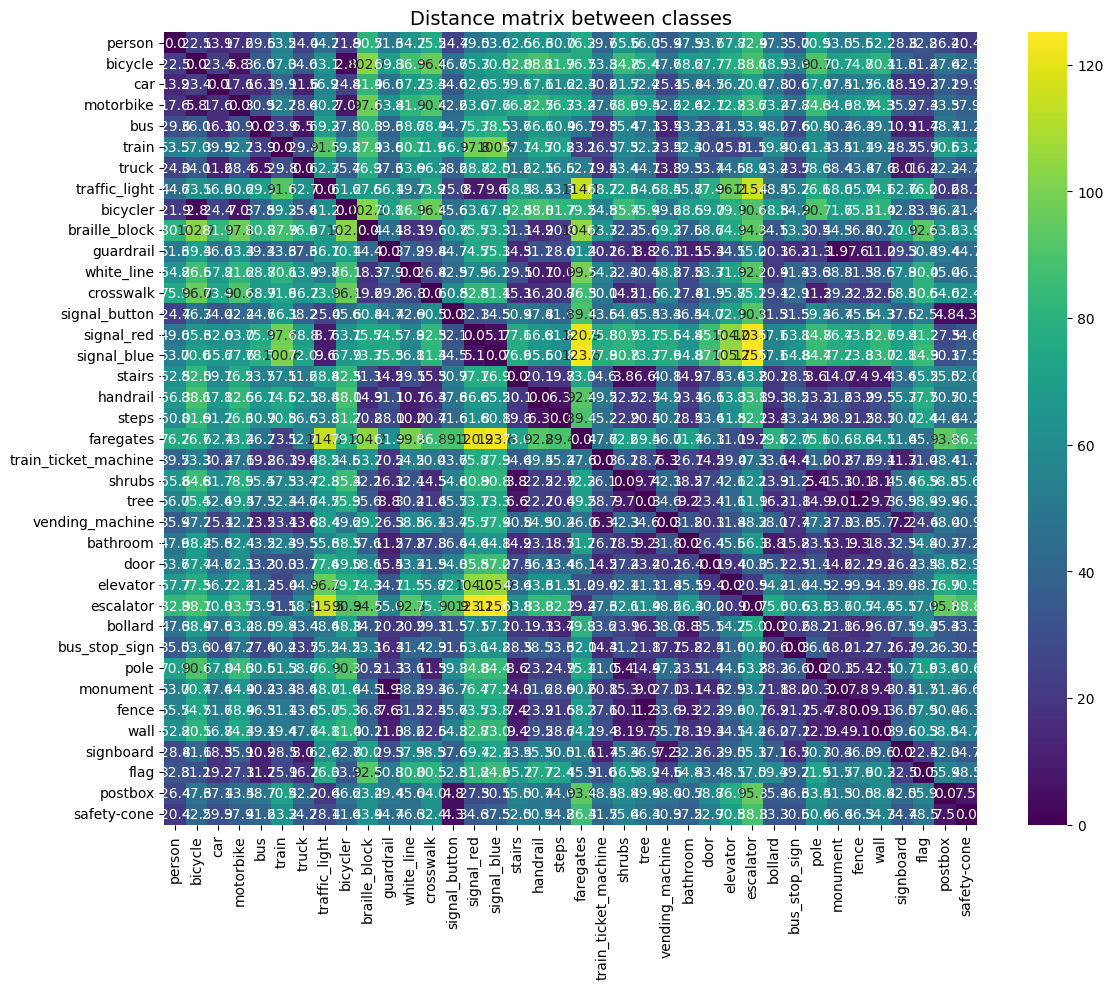

In [33]:
if len(unique_labels) > 1:
    class_centers = {}
    for class_id in unique_labels:
        mask = labels == class_id
        class_centers[class_id] = np.mean(features_2d[mask], axis=0)

    distance_matrix = np.zeros((len(unique_labels), len(unique_labels)))
    for i, c1 in enumerate(unique_labels):
        for j, c2 in enumerate(unique_labels):
            if i < j:
                distance = np.linalg.norm(class_centers[c1] - class_centers[c2])
                distance_matrix[i, j] = distance
                distance_matrix[j, i] = distance
                print(f"Distance between {class_names[c1]} and {class_names[c2]}: {distance:.2f}")

    non_zero_indices = np.where(distance_matrix > 0)
    min_idx = np.argmin(distance_matrix[non_zero_indices])
    min_i, min_j = non_zero_indices[0][min_idx], non_zero_indices[1][min_idx]
    closest_pair = (unique_labels[min_i], unique_labels[min_j])
    print(f"Closest pair: {class_names[closest_pair[0]]} and {class_names[closest_pair[1]]}")

    max_idx = np.argmax(distance_matrix)
    max_i, max_j = max_idx // len(unique_labels), max_idx % len(unique_labels)
    farthest_pair = (unique_labels[max_i], unique_labels[max_j])
    print(f"Farthest pair: {class_names[farthest_pair[0]]} and {class_names[farthest_pair[1]]}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        distance_matrix,
        xticklabels=[class_names[id] for id in unique_labels],
        yticklabels=[class_names[id] for id in unique_labels],
        annot=True,
        cmap='viridis',
        fmt='.1f'
    )
    plt.title('Distance matrix between classes', fontsize=14)
    plt.tight_layout()
    plt.savefig('distance_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

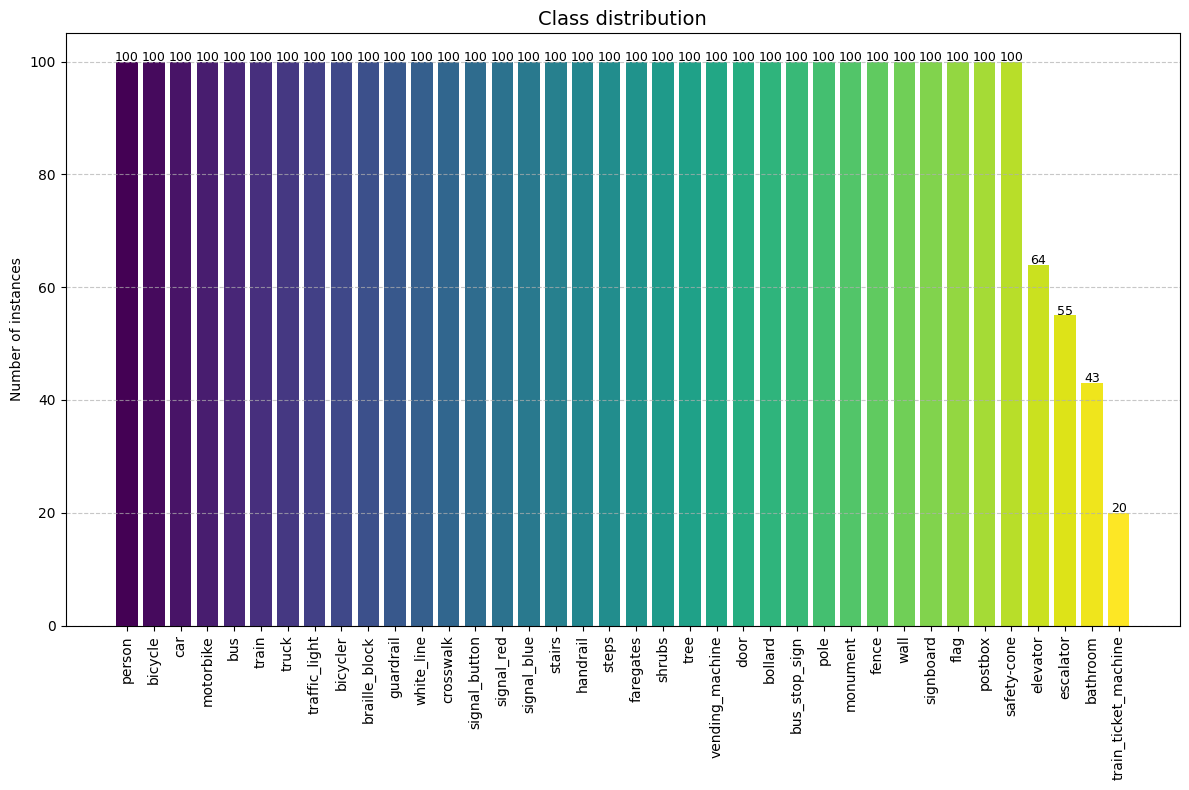

In [34]:
if features.shape[0] > 1:
    class_counts = {}
    for class_id in np.unique(labels):
        class_counts[class_names[class_id]] = np.sum(labels == class_id)

    sorted_counts = {k: v for k, v in sorted(class_counts.items(), key=lambda item: item[1], reverse=True)}
    
    plt.figure(figsize=(12, 8))
    
    bars = plt.bar(
        sorted_counts.keys(),
        sorted_counts.values(),
        color=plt.cm.viridis(np.linspace(0, 1, len(sorted_counts)))
    )
    
    plt.title('Class distribution', fontsize=14)
    plt.xticks(rotation=90)
    plt.ylabel('Number of instances')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.1,
            f'{int(height)}',
            ha='center',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()